# Продвинутые RAG-техники

**Содержание**

1. Подготовка окружения и данных
2. Baseline RAG + метрики
3. Query Expansion (HyDE, Multi-Query)
4. Multi-stage Reranking
5. Parent Document Retrieval
6. Contextual Retrieval
7. Late Chunking
8. Context Compression
9. Multi-hop Retrieval
10. Agentic RAG
11. GraphRAG
12. Сводная таблица результатов
13. Парсинг PDF (PaddleOCR, Docling, Marker)

## Часть 1. Подготовка окружения и данных

In [ ]:
# Установка зависимостей (Google Colab)
!pip install -q langchain langchain-community langchain-openai \
    chromadb sentence-transformers rank_bm25 \
    ragas datasets openai tiktoken \
    FlagEmbedding

In [ ]:
import os
import json
import numpy as np
from typing import List, Dict
from collections import defaultdict

# Ключ OpenAI для LLM (замените на свой или используйте бесплатную модель)
# Можно использовать любую LLM: Gemini, Mistral, Llama через Ollama
os.environ["OPENAI_API_KEY"] = "sk-..."  # <-- вставьте свой ключ

### 1.1 Создаем тестовый корпус документов
Небольшая база знаний из 10 документов для демонстрации всех техник.

In [ ]:
# Корпус документов: имитация корпоративной базы знаний
DOCUMENTS = [
    {
        "id": "doc_1",
        "title": "Политика возврата товаров",
        "content": """Возврат товара возможен в течение 14 дней с момента покупки.
Товар должен быть в оригинальной упаковке, без следов использования.
Электроника возвращается в течение 7 дней. Возврат денежных средств
осуществляется на карту в течение 5-10 рабочих дней. Для возврата
необходим чек или электронный заказ. Товары категории "гигиена"
возврату не подлежат.""",
    },
    {
        "id": "doc_2",
        "title": "Доставка и сроки",
        "content": """Стандартная доставка занимает 3-5 рабочих дней.
Экспресс-доставка: 1-2 рабочих дня, стоимость 500 рублей.
Бесплатная доставка при заказе от 5000 рублей.
Доставка в пункты выдачи: 2-4 рабочих дня, бесплатно.
Отслеживание доступно в личном кабинете по номеру заказа.
Доставка в выходные дни не осуществляется.""",
    },
    {
        "id": "doc_3",
        "title": "Программа лояльности",
        "content": """Программа лояльности имеет 3 уровня: Бронза, Серебро, Золото.
Бронза: 1% кэшбэк на все покупки, начисляется автоматически.
Серебро: 3% кэшбэк + бесплатная доставка (от 20000 руб. покупок за год).
Золото: 5% кэшбэк + приоритетная поддержка (от 50000 руб. за год).
Баллы можно потратить на следующую покупку. 1 балл = 1 рубль.
Баллы сгорают через 12 месяцев после начисления.""",
    },
    {
        "id": "doc_4",
        "title": "Гарантийное обслуживание",
        "content": """Гарантия на электронику: 12 месяцев с даты покупки.
Гарантия на одежду и обувь: 30 дней. Гарантийный ремонт занимает
до 14 рабочих дней. Для гарантийного обращения нужен чек и
гарантийный талон. Механические повреждения не являются
гарантийным случаем. Расширенная гарантия (+12 месяцев)
доступна за 10% от стоимости товара.""",
    },
    {
        "id": "doc_5",
        "title": "Способы оплаты",
        "content": """Принимаем оплату: банковские карты Visa, Mastercard, МИР.
Оплата через СБП (Система быстрых платежей) без комиссии.
Оплата при получении доступна для заказов до 15000 рублей.
Рассрочка от банков-партнеров: 0% на 6 месяцев при покупке от 10000 руб.
Оплата бонусными баллами: до 50% от суммы заказа.
Подарочные сертификаты: номинал 1000, 3000, 5000 рублей.""",
    },
    {
        "id": "doc_6",
        "title": "Контакты и время работы",
        "content": """Горячая линия: 8-800-123-45-67 (бесплатно по России).
Время работы поддержки: пн-пт 9:00-21:00, сб-вс 10:00-18:00.
Email: support@shop.ru, ответ в течение 24 часов.
Чат на сайте: круглосуточно, среднее время ответа 2 минуты.
Офис: Москва, ул. Примерная, д. 10. Время работы: пн-пт 10:00-19:00.
Социальные сети: VK, Telegram — @shopofficial.""",
    },
    {
        "id": "doc_7",
        "title": "Подписка Premium",
        "content": """Подписка Premium: 299 руб/мес или 2990 руб/год.
Включает: бесплатную доставку на все заказы, приоритетную
поддержку 24/7, ранний доступ к распродажам, эксклюзивные
скидки до 15%. Первые 30 дней бесплатно. Отмена в любой момент
в личном кабинете. Premium-подписчики получают удвоенные баллы
лояльности. Автопродление можно отключить.""",
    },
    {
        "id": "doc_8",
        "title": "Акции и скидки",
        "content": """Текущие акции: Черная пятница — скидки до 70% на электронику.
Акция "Приведи друга": получите 500 бонусных баллов за каждого
приглашенного друга, который сделает покупку. Сезонная распродажа
зимней коллекции: скидки 30-50%. Промокод WELCOME10 дает скидку
10% на первый заказ. Акции не суммируются между собой.
Скидки по промокоду не распространяются на товары со скидкой.""",
    },
    {
        "id": "doc_9",
        "title": "Обмен товара",
        "content": """Обмен товара возможен в течение 14 дней. Обмен на аналогичный
товар другого размера или цвета — бесплатно. Обмен на товар другой
категории возможен с доплатой или возвратом разницы. Обмен
электроники: только на идентичную модель при наличии на складе.
Для обмена обратитесь в службу поддержки или в пункт выдачи.
Обмен товаров категории "нижнее белье" невозможен.""",
    },
    {
        "id": "doc_10",
        "title": "Корпоративные продажи",
        "content": """Корпоративные клиенты получают скидку от 15% при заказе от
50 единиц. Выделенный менеджер для компаний. Оплата по счету
с отсрочкой до 30 дней. Индивидуальные условия доставки.
Брендирование продукции: нанесение логотипа от 100 единиц.
Для оформления корпоративного аккаунта необходимы ИНН и
реквизиты компании. Контакт: b2b@shop.ru.""",
    },
]

print(f"Загружено {len(DOCUMENTS)} документов")

### 1.2 Golden Dataset: 20 вопросов с эталонными ответами

In [ ]:
# Golden dataset: вопрос + ID релевантного документа
# Это основа для вычисления MRR и Hit Rate
GOLDEN_DATASET = [
    {"question": "Сколько дней дается на возврат товара?", "relevant_doc": "doc_1"},
    {"question": "Можно ли вернуть электронику?", "relevant_doc": "doc_1"},
    {"question": "Сколько стоит экспресс-доставка?", "relevant_doc": "doc_2"},
    {"question": "Когда доставка бесплатная?", "relevant_doc": "doc_2"},
    {"question": "Какие уровни программы лояльности?", "relevant_doc": "doc_3"},
    {"question": "Когда сгорают бонусные баллы?", "relevant_doc": "doc_3"},
    {"question": "Сколько длится гарантия на электронику?", "relevant_doc": "doc_4"},
    {"question": "Можно ли купить расширенную гарантию?", "relevant_doc": "doc_4"},
    {"question": "Есть ли рассрочка?", "relevant_doc": "doc_5"},
    {"question": "Можно ли оплатить бонусами?", "relevant_doc": "doc_5"},
    {"question": "Как связаться с поддержкой?", "relevant_doc": "doc_6"},
    {"question": "Во сколько закрывается поддержка в выходные?", "relevant_doc": "doc_6"},
    {"question": "Сколько стоит подписка Premium?", "relevant_doc": "doc_7"},
    {"question": "Что входит в Premium?", "relevant_doc": "doc_7"},
    {"question": "Какие сейчас акции?", "relevant_doc": "doc_8"},
    {"question": "Какой промокод на первый заказ?", "relevant_doc": "doc_8"},
    {"question": "Можно ли обменять товар на другой размер?", "relevant_doc": "doc_9"},
    {"question": "Можно ли обменять нижнее белье?", "relevant_doc": "doc_9"},
    {"question": "Какая скидка для корпоративных клиентов?", "relevant_doc": "doc_10"},
    {"question": "Как оформить корпоративный аккаунт?", "relevant_doc": "doc_10"},
]

print(f"Golden dataset: {len(GOLDEN_DATASET)} вопросов")

### 1.3 Функции для вычисления метрик

In [ ]:
def compute_metrics(results: List[Dict], k: int = 3) -> Dict[str, float]:
    """
    Вычисляет метрики retrieval по результатам поиска.

    Args:
        results: список словарей {question, relevant_doc, retrieved_docs}
                 retrieved_docs — список ID документов в порядке ранжирования
        k: top-K для Hit Rate

    Returns:
        dict с метриками MRR, Hit Rate@K, NDCG@K
    """
    mrr_scores = []
    hit_scores = []

    for r in results:
        relevant = r["relevant_doc"]
        retrieved = r["retrieved_docs"][:k]

        # MRR: 1 / позиция первого релевантного документа
        if relevant in retrieved:
            rank = retrieved.index(relevant) + 1
            mrr_scores.append(1.0 / rank)
            hit_scores.append(1)
        else:
            mrr_scores.append(0.0)
            hit_scores.append(0)

    return {
        "MRR": round(np.mean(mrr_scores), 4),
        "Hit_Rate@3": round(np.mean(hit_scores), 4),
        "Hits": f"{sum(hit_scores)}/{len(results)}",
    }


def print_metrics(name: str, metrics: Dict):
    """Красивый вывод метрик."""
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  MRR:         {metrics['MRR']:.4f}")
    print(f"  Hit Rate@3:  {metrics['Hit_Rate@3']:.4f}")
    print(f"  Hits:        {metrics['Hits']}")
    print(f"{'='*50}")

    return metrics

---
## Часть 2. Baseline RAG

Простейший RAG: разбиваем документы на чанки, создаем эмбеддинги, ищем top-3.

In [ ]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

# Эмбеддинг-модель: маленькая, быстрая, бесплатная
embed_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Разбиваем документы на чанки
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,    # максимальный размер чанка в символах
    chunk_overlap=50,  # перекрытие между чанками
)

# Создаем чанки с метаданными (ID документа)
chunks = []
metadatas = []
for doc in DOCUMENTS:
    doc_chunks = splitter.split_text(doc["content"])
    for chunk in doc_chunks:
        chunks.append(chunk)
        metadatas.append({"doc_id": doc["id"], "title": doc["title"]})

print(f"Всего чанков: {len(chunks)}")
print(f"Пример чанка: {chunks[0][:100]}...")

In [ ]:
# Создаем векторное хранилище
vectorstore = Chroma.from_texts(
    texts=chunks,
    metadatas=metadatas,
    embedding=embed_model,
    collection_name="baseline"
)

# Функция поиска: возвращает top-K документов
def baseline_retrieve(question: str, k: int = 3) -> List[str]:
    """Базовый векторный поиск."""
    results = vectorstore.similarity_search(question, k=k)
    # Извлекаем уникальные doc_id в порядке ранжирования
    doc_ids = []
    for r in results:
        doc_id = r.metadata["doc_id"]
        if doc_id not in doc_ids:
            doc_ids.append(doc_id)
    return doc_ids

In [ ]:
# Замеряем метрики Baseline RAG
baseline_results = []
for item in GOLDEN_DATASET:
    retrieved = baseline_retrieve(item["question"])
    baseline_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

baseline_metrics = print_metrics("Baseline RAG", compute_metrics(baseline_results))

### Сохраняем результаты для сравнения

In [ ]:
# Таблица результатов: будем дополнять по мере прохождения техник
ALL_RESULTS = {"Baseline RAG": baseline_metrics}

---
## Часть 3. Query Expansion (HyDE + Multi-Query)

**Идея:** LLM генерирует вариации запроса для покрытия разных формулировок.
Это улучшает recall, так как пользователь может сформулировать вопрос по-разному.

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def expand_query(question: str, n: int = 3) -> List[str]:
    """
    Генерирует N вариаций поискового запроса.
    Multi-Query: ищем по нескольким формулировкам одновременно.
    """
    prompt = f"""Сгенерируй {n} разных поисковых запроса для поиска ответа на вопрос.
Каждый запрос должен передавать тот же смысл, но другими словами.
Верни только список запросов, по одному на строку. Без нумерации.

Вопрос: {question}"""

    response = llm.invoke(prompt)
    queries = [q.strip() for q in response.content.strip().split("\n") if q.strip()]
    return [question] + queries[:n]  # оригинал + вариации


def query_expansion_retrieve(question: str, k: int = 3) -> List[str]:
    """Поиск по нескольким вариациям запроса с дедупликацией."""
    queries = expand_query(question)
    all_doc_ids = []
    for q in queries:
        results = vectorstore.similarity_search(q, k=k)
        for r in results:
            doc_id = r.metadata["doc_id"]
            if doc_id not in all_doc_ids:
                all_doc_ids.append(doc_id)
    return all_doc_ids[:k]

In [ ]:
# Замеряем метрики Query Expansion
qe_results = []
for item in GOLDEN_DATASET:
    retrieved = query_expansion_retrieve(item["question"])
    qe_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

qe_metrics = print_metrics("Query Expansion", compute_metrics(qe_results))
ALL_RESULTS["Query Expansion"] = qe_metrics

---
## Часть 4. Multi-stage Reranking

**Идея:** Bi-encoder (быстрый, но грубый) находит top-20 кандидатов.
Cross-encoder (медленный, но точный) переранжирует их в top-3.
Каскад дает качество cross-encoder при скорости bi-encoder.

In [ ]:
from sentence_transformers import CrossEncoder

# Cross-encoder для переранжирования
# Он принимает пару (query, document) и возвращает score релевантности
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def reranking_retrieve(question: str, k: int = 3) -> List[str]:
    """
    Stage 1: Bi-encoder находит top-10 кандидатов (быстро).
    Stage 2: Cross-encoder переранжирует до top-K (точно).
    """
    # Stage 1: грубый поиск
    candidates = vectorstore.similarity_search(question, k=10)

    # Stage 2: точное переранжирование
    pairs = [(question, c.page_content) for c in candidates]
    scores = reranker.predict(pairs)

    # Сортируем по score cross-encoder
    ranked = sorted(
        zip(scores, candidates),
        key=lambda x: x[0],
        reverse=True
    )

    # Извлекаем уникальные doc_id
    doc_ids = []
    for score, doc in ranked:
        doc_id = doc.metadata["doc_id"]
        if doc_id not in doc_ids:
            doc_ids.append(doc_id)
    return doc_ids[:k]

In [ ]:
# Замеряем метрики Reranking
rr_results = []
for item in GOLDEN_DATASET:
    retrieved = reranking_retrieve(item["question"])
    rr_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

rr_metrics = print_metrics("Multi-stage Reranking", compute_metrics(rr_results))
ALL_RESULTS["Reranking"] = rr_metrics

---
## Часть 5. Parent Document Retrieval

**Идея:** Ищем по маленьким чанкам (точный поиск), но возвращаем большой родительский документ (полный контекст для LLM).
Small chunks = лучший retrieval, Large chunks = лучшая генерация.

In [ ]:
# Создаем два уровня чанкинга
child_splitter = RecursiveCharacterTextSplitter(chunk_size=150, chunk_overlap=20)
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=50)

# Индекс: child_chunk -> parent_doc_id
child_chunks = []
child_metadatas = []
parent_store = {}  # doc_id -> полный текст

for doc in DOCUMENTS:
    parent_store[doc["id"]] = doc["content"]
    small_chunks = child_splitter.split_text(doc["content"])
    for chunk in small_chunks:
        child_chunks.append(chunk)
        child_metadatas.append({"doc_id": doc["id"], "title": doc["title"]})

# Создаем отдельное хранилище для маленьких чанков
parent_vectorstore = Chroma.from_texts(
    texts=child_chunks,
    metadatas=child_metadatas,
    embedding=embed_model,
    collection_name="parent_doc"
)

def parent_doc_retrieve(question: str, k: int = 3) -> List[str]:
    """
    Ищем по маленьким чанкам, возвращаем ID родительского документа.
    Маленькие чанки = точнее попадаем в нужный фрагмент.
    """
    results = parent_vectorstore.similarity_search(question, k=k * 2)
    doc_ids = []
    for r in results:
        doc_id = r.metadata["doc_id"]
        if doc_id not in doc_ids:
            doc_ids.append(doc_id)
    return doc_ids[:k]

print(f"Child chunks: {len(child_chunks)} (avg ~{np.mean([len(c) for c in child_chunks]):.0f} chars)")

In [ ]:
# Замеряем метрики Parent Document Retrieval
pd_results = []
for item in GOLDEN_DATASET:
    retrieved = parent_doc_retrieve(item["question"])
    pd_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

pd_metrics = print_metrics("Parent Doc Retrieval", compute_metrics(pd_results))
ALL_RESULTS["Parent Doc"] = pd_metrics

---
## Часть 6. Contextual Retrieval (Anthropic, 2024)

**Идея:** LLM добавляет контекст документа к каждому чанку перед эмбеддингом.
Решает проблему анафор: чанк "Его цена 500 руб" не знает, что "его" = товар X.

In [ ]:
def contextualize_chunk(full_doc: str, chunk: str, title: str) -> str:
    """
    LLM генерирует 1-2 предложения контекста, ситуирующие чанк в документе.
    Результат: [контекст] + чанк -> более информативный эмбеддинг.
    """
    prompt = f"""Документ: "{title}"
Полный текст: {full_doc[:500]}

Чанк: {chunk}

Дай 1-2 предложения контекста, которые объясняют, о чем этот чанк
в рамках документа. Только контекст, без лишних слов."""

    response = llm.invoke(prompt)
    context = response.content.strip()
    return f"[Контекст: {context}] {chunk}"


# Создаем контекстуализированные чанки
ctx_chunks = []
ctx_metadatas = []

for doc in DOCUMENTS:
    doc_chunks = splitter.split_text(doc["content"])
    for chunk in doc_chunks:
        enriched = contextualize_chunk(doc["content"], chunk, doc["title"])
        ctx_chunks.append(enriched)
        ctx_metadatas.append({"doc_id": doc["id"], "title": doc["title"]})

print(f"Contextualized chunks: {len(ctx_chunks)}")
print(f"\nПример:\n{ctx_chunks[0][:200]}...")

In [ ]:
# Создаем хранилище с контекстуализированными чанками
ctx_vectorstore = Chroma.from_texts(
    texts=ctx_chunks,
    metadatas=ctx_metadatas,
    embedding=embed_model,
    collection_name="contextual"
)

def contextual_retrieve(question: str, k: int = 3) -> List[str]:
    """Поиск по контекстуализированным чанкам."""
    results = ctx_vectorstore.similarity_search(question, k=k)
    doc_ids = []
    for r in results:
        doc_id = r.metadata["doc_id"]
        if doc_id not in doc_ids:
            doc_ids.append(doc_id)
    return doc_ids[:k]

In [ ]:
# Замеряем метрики Contextual Retrieval
cr_results = []
for item in GOLDEN_DATASET:
    retrieved = contextual_retrieve(item["question"])
    cr_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

cr_metrics = print_metrics("Contextual Retrieval", compute_metrics(cr_results))
ALL_RESULTS["Contextual Retrieval"] = cr_metrics

---
## Часть 7. Late Chunking (Jina AI)

**Идея:** Сначала прогоняем весь документ через embedding-модель (self-attention видит все).
Потом делим на чанки с span pooling. Каждый токен уже "знает" контекст.
Нет дополнительных LLM-вызовов (в отличие от Contextual Retrieval).

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

# Используем модель с длинным контекстом
# В реальном проекте: jina-embeddings-v3 (до 8192 токенов)
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def late_chunking_embed(full_text: str, chunk_size: int = 150) -> List[np.ndarray]:
    """
    Late Chunking: embed full doc, then pool by chunk boundaries.

    1. Токенизируем весь документ
    2. Прогоняем через модель
    3. Делим token embeddings на чанки
    4. Для каждого чанка: mean pooling его токенов (усреднение векторов)
    В результате каждый отдельный чанк знает контекст всего документа
    """
    # Токенизация всего документа
    inputs = tokenizer(full_text, return_tensors="pt",
                       truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)
    token_embeds = outputs.last_hidden_state[0]  # [seq_len, hidden_dim]

    # Определяем границы чанков по символам -> по токенам
    text_chunks = []
    chunk_embeds = []
    tokens = tokenizer.tokenize(full_text)

    # Простое разбиение токенов на группы
    chunk_token_size = max(1, len(tokens) // max(1, len(full_text) // chunk_size))
    for i in range(0, len(tokens), chunk_token_size):
        end = min(i + chunk_token_size, len(tokens))
        # +1 для CLS токена
        chunk_embed = token_embeds[i+1:end+1].mean(dim=0).numpy()
        chunk_embeds.append(chunk_embed)
        text_chunks.append(tokenizer.convert_tokens_to_string(tokens[i:end]))

    return text_chunks, chunk_embeds

# Демонстрация
demo_chunks, demo_embeds = late_chunking_embed(DOCUMENTS[0]["content"])
print(f"Document: {DOCUMENTS[0]['title']}")
print(f"Late chunks: {len(demo_chunks)}")
print(f"Embedding dim: {demo_embeds[0].shape}")

In [ ]:
# Создаем индекс с late chunking эмбеддингами
lc_chunks = []
lc_embeds = []
lc_metadatas = []

for doc in DOCUMENTS:
    text_chunks, chunk_embeddings = late_chunking_embed(doc["content"])
    for chunk, emb in zip(text_chunks, chunk_embeddings):
        lc_chunks.append(chunk)
        lc_embeds.append(emb.tolist())
        lc_metadatas.append({"doc_id": doc["id"], "title": doc["title"]})

# Создаем хранилище
lc_vectorstore = Chroma.from_texts(
    texts=lc_chunks,
    metadatas=lc_metadatas,
    embedding=embed_model,
    collection_name="late_chunking"
)

def late_chunking_retrieve(question: str, k: int = 3) -> List[str]:
    results = lc_vectorstore.similarity_search(question, k=k)
    doc_ids = []
    for r in results:
        doc_id = r.metadata["doc_id"]
        if doc_id not in doc_ids:
            doc_ids.append(doc_id)
    return doc_ids[:k]

In [ ]:
# Замеряем метрики Late Chunking
lc_results = []
for item in GOLDEN_DATASET:
    retrieved = late_chunking_retrieve(item["question"])
    lc_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

lc_metrics = print_metrics("Late Chunking", compute_metrics(lc_results))
ALL_RESULTS["Late Chunking"] = lc_metrics

---
## Часть 8. Context Compression

**Идея:** Сжимаем извлеченные чанки, оставляя только релевантную запросу часть.
Меньше шума в контексте LLM = лучше Faithfulness, меньше токенов.

In [ ]:
def compress_context(question: str, chunks: list) -> List[str]:
    """
    LLM извлекает только релевантные предложения из каждого чанка.
    Это уменьшает количество токенов и убирает шум.
    """
    compressed = []
    for chunk_text in chunks:
        prompt = f"""Извлеки только те предложения, которые отвечают на вопрос.
Если ничего релевантного нет, верни "НЕ РЕЛЕВАНТНО".

Вопрос: {question}
Текст: {chunk_text}

Релевантные предложения:"""
        response = llm.invoke(prompt)
        result = response.content.strip()
        if "НЕ РЕЛЕВАНТНО" not in result:
            compressed.append(result)
    return compressed


def compression_retrieve(question: str, k: int = 3) -> List[str]:
    """Retrieval + сжатие контекста."""
    # Достаем больше кандидатов, потом фильтруем
    results = vectorstore.similarity_search(question, k=k * 2)
    doc_ids = []
    for r in results:
        doc_id = r.metadata["doc_id"]
        if doc_id not in doc_ids:
            doc_ids.append(doc_id)
    return doc_ids[:k]

# Для метрик retrieval Context Compression дает те же результаты,
# что и baseline (сжатие влияет на generation, не на retrieval).
# Покажем эффект сжатия:
example_q = "Сколько стоит экспресс-доставка?"
example_chunks = [r.page_content for r in vectorstore.similarity_search(example_q, k=3)]
compressed = compress_context(example_q, example_chunks)

print(f"Вопрос: {example_q}")
print(f"\nДо сжатия ({sum(len(c) for c in example_chunks)} chars):")
for c in example_chunks:
    print(f"  {c[:80]}...")
print(f"\nПосле сжатия ({sum(len(c) for c in compressed)} chars):")
for c in compressed:
    print(f"  {c}")

ALL_RESULTS["Context Compression"] = ALL_RESULTS["Baseline RAG"].copy()
print("\nContext Compression влияет на Generation quality, не на Retrieval metrics.")
print("Retrieval метрики = Baseline. Выигрыш: -30-50% токенов, +Faithfulness.")

---
## Часть 9. Multi-hop Retrieval

**Идея:** Итеративный поиск: ответ на первый подвопрос используется для генерации следующего запроса. Для сложных вопросов, требующих связи фактов из разных документов.

In [ ]:
def multi_hop_retrieve(question: str, max_hops: int = 2, k: int = 3) -> List[str]:
    """
    Multi-hop: итеративный поиск с генерацией follow-up запросов.

    Hop 1: Ищем по исходному вопросу
    Hop 2: LLM анализирует найденное и генерирует уточняющий запрос
    """
    all_doc_ids = []
    current_query = question
    context_so_far = []

    for hop in range(max_hops):
        # Поиск
        results = vectorstore.similarity_search(current_query, k=k)

        for r in results:
            doc_id = r.metadata["doc_id"]
            if doc_id not in all_doc_ids:
                all_doc_ids.append(doc_id)
            context_so_far.append(r.page_content)

        if hop < max_hops - 1:
            # Генерируем follow-up запрос на основе найденного
            prompt = f"""Вопрос пользователя: {question}
Найденная информация: {' '.join(context_so_far[-3:])}

Какой дополнительный поисковый запрос поможет полнее ответить на вопрос?
Если информации достаточно, верни "ДОСТАТОЧНО".
Иначе верни только поисковый запрос."""

            response = llm.invoke(prompt)
            next_query = response.content.strip()
            if "ДОСТАТОЧНО" in next_query:
                break
            current_query = next_query

    return all_doc_ids[:k]

In [ ]:
# Замеряем метрики Multi-hop
mh_results = []
for item in GOLDEN_DATASET:
    retrieved = multi_hop_retrieve(item["question"])
    mh_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

mh_metrics = print_metrics("Multi-hop Retrieval", compute_metrics(mh_results))
ALL_RESULTS["Multi-hop"] = mh_metrics

---
## Часть 10. Agentic RAG

**Когда нужен:** Multi-step задачи, cross-system retrieval (БД + API + vector store), сложная аналитика.
Агент сам решает: нужно ли переформулировать запрос, в какой источник идти, достаточно ли данных.

**Отличие от обычного RAG:** агент имеет цикл self-critique и может повторить поиск.

In [ ]:
def agentic_retrieve(question: str, k: int = 3, max_retries: int = 2) -> List[str]:
    """
    Agentic RAG: агент с самокоррекцией.

    1. Ищем по запросу
    2. LLM-judge оценивает: достаточно ли найденного для ответа?
    3. Если нет -> переформулируем запрос и ищем снова
    """
    current_query = question
    all_doc_ids = []

    for attempt in range(max_retries + 1):
        results = vectorstore.similarity_search(current_query, k=k)
        found_texts = [r.page_content for r in results]

        for r in results:
            doc_id = r.metadata["doc_id"]
            if doc_id not in all_doc_ids:
                all_doc_ids.append(doc_id)

        # Self-critique: оцениваем качество найденного
        judge_prompt = f"""Вопрос: {question}
Найденные документы:
{chr(10).join(found_texts[:3])}

Можно ли ответить на вопрос по этим документам? (ДА/НЕТ)
Если НЕТ, предложи переформулированный поисковый запрос."""

        judge_response = llm.invoke(judge_prompt)
        response_text = judge_response.content.strip()

        if "ДА" in response_text.upper():
            break  # Достаточно информации
        else:
            # Извлекаем новый запрос
            lines = response_text.split("\n")
            current_query = lines[-1] if len(lines) > 1 else question

    return all_doc_ids[:k]

In [ ]:
# Замеряем метрики Agentic RAG
ar_results = []
for item in GOLDEN_DATASET:
    retrieved = agentic_retrieve(item["question"])
    ar_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

ar_metrics = print_metrics("Agentic RAG", compute_metrics(ar_results))
ALL_RESULTS["Agentic RAG"] = ar_metrics

---
## Часть 11. GraphRAG (упрощенная демонстрация)

**Когда нужен:** Multi-hop вопросы между связанными сущностями, "global" вопросы ("какие основные темы?"), enterprise KB с иерархией.

**Упрощение:** Для полного GraphRAG нужен Neo4j + LLM entity extraction.
Здесь показываем концепцию: извлечение сущностей -> граф связей -> поиск по графу.

In [ ]:
# Упрощенный GraphRAG: строим граф сущностей из документов
def extract_entities(text: str, title: str) -> List[Dict]:
    """LLM извлекает сущности и связи из текста."""
    prompt = f"""Извлеки сущности и их связи из текста. Формат JSON:
[{{"entity": "название", "type": "тип", "relations": ["связанная_сущность1"]}}]

Текст ({title}): {text[:400]}

JSON:"""
    response = llm.invoke(prompt)
    try:
        # Пытаемся распарсить JSON из ответа
        content = response.content.strip()
        if "```" in content:
            content = content.split("```")[1].replace("json", "").strip()
        return json.loads(content)
    except:
        return []

# Строим граф
knowledge_graph = {}  # entity -> {doc_ids, relations}

for doc in DOCUMENTS:
    entities = extract_entities(doc["content"], doc["title"])
    for ent in entities:
        name = ent.get("entity", "").lower()
        if name:
            if name not in knowledge_graph:
                knowledge_graph[name] = {"doc_ids": set(), "relations": set()}
            knowledge_graph[name]["doc_ids"].add(doc["id"])
            for rel in ent.get("relations", []):
                knowledge_graph[name]["relations"].add(rel.lower())

print(f"Граф: {len(knowledge_graph)} сущностей")
for name, info in list(knowledge_graph.items())[:5]:
    print(f"  {name}: docs={info['doc_ids']}, rels={list(info['relations'])[:3]}")

In [ ]:
def graphrag_retrieve(question: str, k: int = 3) -> List[str]:
    """
    GraphRAG: ищем по графу сущностей + fallback на вектор.

    1. Извлекаем сущности из вопроса
    2. Ищем их в графе знаний
    3. Через связи находим дополнительные документы
    4. Если граф не помог -> fallback на векторный поиск
    """
    # Извлекаем ключевые слова из вопроса
    q_lower = question.lower()
    matched_docs = set()

    for entity, info in knowledge_graph.items():
        if entity in q_lower or any(word in entity for word in q_lower.split() if len(word) > 3):
            matched_docs.update(info["doc_ids"])
            # Переходим по связям (1 hop)
            for rel in info["relations"]:
                if rel in knowledge_graph:
                    matched_docs.update(knowledge_graph[rel]["doc_ids"])

    if matched_docs:
        return list(matched_docs)[:k]

    # Fallback: обычный векторный поиск
    return baseline_retrieve(question, k)

In [ ]:
# Замеряем метрики GraphRAG
gr_results = []
for item in GOLDEN_DATASET:
    retrieved = graphrag_retrieve(item["question"])
    gr_results.append({
        "question": item["question"],
        "relevant_doc": item["relevant_doc"],
        "retrieved_docs": retrieved,
    })

gr_metrics = print_metrics("GraphRAG", compute_metrics(gr_results))
ALL_RESULTS["GraphRAG"] = gr_metrics

---
## Часть 12. Сводная таблица результатов

In [ ]:
import pandas as pd

# Собираем все результаты в таблицу
rows = []
for name, metrics in ALL_RESULTS.items():
    rows.append({
        "Техника": name,
        "MRR": metrics["MRR"],
        "Hit Rate@3": metrics["Hit_Rate@3"],
        "Hits": metrics["Hits"],
    })

df = pd.DataFrame(rows)
df = df.sort_values("MRR", ascending=False).reset_index(drop=True)

print("=" * 60)
print("  СВОДНАЯ ТАБЛИЦА: RAG-ТЕХНИКИ vs МЕТРИКИ")
print("=" * 60)
print(df.to_string(index=False))
print("=" * 60)

# Визуализация
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df))
width = 0.35
ax.bar([i - width/2 for i in x], df["MRR"], width, label="MRR", color="#378FF6")
ax.bar([i + width/2 for i in x], df["Hit Rate@3"], width, label="Hit Rate@3", color="#10B981")
ax.set_xticks(x)
ax.set_xticklabels(df["Техника"], rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("RAG Techniques: MRR & Hit Rate@3")
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.75, color="gray", linestyle="--", alpha=0.5, label="Target MRR")
plt.tight_layout()
plt.show()

---
## Часть 13. Парсинг PDF: таблицы, картинки, сканы

Сравнение 4 инструментов для извлечения текста из сложных PDF-документов.

## Среда выполнения - Сменить среду выполнения - GPU (T4)

### 13.1 Docling (IBM, ECIR 2025)
Лучший универсальный парсер. Распознает таблицы, формулы, изображения.
Выдает структурированный Markdown.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ls /content/drive/MyDrive/RAG/RAG.Proglib

 example.pdf                   'Практика 1. Базовые RAG-техники.ipynb'
'RAG. Proglib. 27.04.26.pptx'  'Продвинутые RAG-техники.ipynb'


In [ ]:
# TODO: ЗАМЕНИТЬ НА ВАШ ПУТЬ
path_to_pdf = "/content/drive/MyDrive/RAG/RAG.Proglib/example.pdf"

In [ ]:
questions = [
  {
    "id": 1,
    "question": "Какова была выручка Tower Semiconductor за год, закончившийся 31 декабря 2022 года, и на сколько она увеличилась по сравнению с 2021 годом?",
    "expected_answer": "Выручка за 2022 год составила $1,677.6 млн, что на $169.4 млн больше, чем $1,508.2 млн за 2021 год.",
    "category": "financial_data",
    "difficulty": "easy",
    "reasoning_type": "factual_extraction"
  },
  {
    "id": 2,
    "question": "Какой объём долга был у компании на 31 декабря 2022 года и из каких основных компонентов он состоял?",
    "expected_answer": "Примерно $272 млн консолидированного долга, включая: Series G деbentures (~$19 млн), JP Loan (~$83 млн, фиксированная ставка ~2%), капитальные лизинги с JA Mitsui Leasing (~$110 млн, погашение 2023–2026), прочие капитальные и операционные лизинги (~$60 млн, погашение 2023–2032).",
    "category": "financial_data",
    "difficulty": "medium",
    "reasoning_type": "multi_fact_extraction"
  },
  {
    "id": 3,
    "question": "На каких условиях было заключено соглашение о слиянии с Intel и какова была цена за акцию?",
    "expected_answer": "15 февраля 2022 года заключено соглашение о слиянии (Merger Agreement) с Intel. Цена — $53.00 за акцию. Крайний срок завершения (Outside Date) — 15 августа 2023 года. Штраф за расторжение со стороны Tower — $206 млн, со стороны Intel (при неполучении регуляторных одобрений) — $353 млн. Акционеры одобрили сделку 25 апреля 2022 года.",
    "category": "corporate_events",
    "difficulty": "medium",
    "reasoning_type": "multi_fact_extraction"
  },
  {
    "id": 4,
    "question": "Как распределялась выручка компании за 2022 год по географическим регионам?",
    "expected_answer": "49% — США, 16% — Япония, 26% — Азия (без Японии), 9% — Европа. Для сравнения, в 2021 году: 41%, 22%, 30% и 7% соответственно.",
    "category": "revenue_breakdown",
    "difficulty": "easy",
    "reasoning_type": "factual_extraction"
  },
  {
    "id": 5,
    "question": "Какую долю выручки за 2022 год обеспечил крупнейший клиент и кто это был?",
    "expected_answer": "Крупнейший клиент — NTCJ (Nuvoton Technology Corporation Japan), обеспечил 14% выручки. Ещё 5 клиентов суммарно дали 33% (от 4% до 9% каждый), остальные 53% — от множества мелких клиентов.",
    "category": "customer_concentration",
    "difficulty": "easy",
    "reasoning_type": "factual_extraction"
  },
  {
    "id": 6,
    "question": "Какая ставка корпоративного налога применяется к «Preferred Income» Tower в Израиле и на каком основании?",
    "expected_answer": "Ставка 7.5%. Производственные мощности Tower в Израиле расположены в зоне развития (Zone A) и квалифицируются как Preferred Enterprise в соответствии с Законом о поощрении капитальных инвестиций (Investment Law) с поправками 2011 года. Стандартная ставка корпоративного налога в Израиле — 23%.",
    "category": "taxation",
    "difficulty": "hard",
    "reasoning_type": "cause_effect"
  },
  {
    "id": 7,
    "question": "Сколько сотрудников было у компании на 31 декабря 2022 года и как они распределялись по странам?",
    "expected_answer": "Всего 5,613 сотрудников: 1,649 в Израиле, 1,501 в США, 2,434 в Японии, 29 в других странах (Азиатско-Тихоокеанский регион и Европа).",
    "category": "workforce",
    "difficulty": "easy",
    "reasoning_type": "factual_extraction"
  },
  {
    "id": 8,
    "question": "Какие фабрики входят в производственную сеть Tower Semiconductor и каковы размеры пластин на каждой из них?",
    "expected_answer": "Fab 1 (Мигдаль-ха-Эмек, Израиль) — 150 мм; Fab 2 (Мигдаль-ха-Эмек, Израиль) — 200 мм; Fab 3 (Ньюпорт-Бич, Калифорния) — 200 мм; Uozu E (Тояма, Япония) — 300 мм; Tonami CD (Тояма, Япония) — 200 мм; Arai E (Ниигата, Япония) — прекратила работу в июле 2022; Fab 9 (Сан-Антонио, Техас) — 200 мм; Fab 10 (Аграте, Италия) — 300 мм, строится совместно с ST Microelectronics.",
    "category": "manufacturing",
    "difficulty": "hard",
    "reasoning_type": "multi_fact_extraction"
  },
  {
    "id": 9,
    "question": "Какие риски связаны с арендой Fab 3 в Ньюпорт-Бич?",
    "expected_answer": "Арендодатель начал строительный проект рядом с фабрикой, что может нарушить подачу коммунальных услуг и потребовать временной остановки производства. Кроме того, арендодатель заявляет, что меры NPB Co. по шумоподавлению не соответствуют условиям аренды, и требует судебного признания существенных неисправимых нарушений с правом расторжения договора аренды. NPB Co. оспаривает эти претензии. Аренда продлена до марта 2027 года.",
    "category": "risk_factors",
    "difficulty": "medium",
    "reasoning_type": "cause_effect"
  },
  {
    "id": 10,
    "question": "Как изменились инвестиции компании в основные средства в 2022 году по сравнению с 2021 годом и куда они были направлены?",
    "expected_answer": "Валовые инвестиции в основные средства выросли на 17% — с $314 млн в 2021 до $367 млн в 2022 году. Инвестиции направлены на фабрики в Израиле, Италии, США и Японии для расширения производственных мощностей и удовлетворения растущего спроса.",
    "category": "capital_expenditure",
    "difficulty": "medium",
    "reasoning_type": "comparison"
  }
]

In [ ]:
!pip install -q docling

from docling.document_converter import DocumentConverter

def parse_with_docling(pdf_path: str) -> str:
    """
    Docling: универсальный парсер PDF.
    Распознает: таблицы, формулы, заголовки, изображения.
    Выход: структурированный Markdown.
    """
    converter = DocumentConverter()
    result = converter.convert(pdf_path)

    # Получаем Markdown с сохранением структуры
    markdown_text = result.document.export_to_markdown()
    return markdown_text

# Пример использования (замените путь на свой PDF)
text = parse_with_docling(path_to_pdf)
print(text[:500])
print("Docling: pip install docling")
print("Поддержка: PDF, DOCX, PPTX, HTML, Images")
print("Особенность: TableFormer для таблиц, формулы в LaTeX")

### 13.2 Marker (SuryaOCR)
Быстрый, работает на CPU. Хорош для текстовых PDF и простых таблиц.

In [ ]:
!pip install -q marker-pdf

# Marker: быстрый парсер на базе SuryaOCR
# Работает на CPU, не требует GPU

def parse_with_marker(pdf_path: str) -> str:
    """
    Marker: PDF -> Markdown.
    Быстрый, работает на CPU.
    Хорош для текстовых PDF и простых таблиц.
    """
    from marker.converters.pdf import PdfConverter
    from marker.models import create_model_dict

    models = create_model_dict()
    converter = PdfConverter(artifact_dict=models)
    rendered = converter(pdf_path)

    # rendered.markdown содержит текст с таблицами
    return rendered.markdown

# Пример:
# text = parse_with_marker("example.pdf")
print("Marker: pip install marker-pdf")
print("Особенность: SuryaOCR, работает на CPU")
print("Лучше всего: текстовые PDF, простые таблицы")

### 13.3 PaddleOCR / PaddleOCR-VL-1.5
Мощный OCR для сканов. PaddleOCR-VL-1.5 -- vision-language модель, 4GB.

In [ ]:
!pip install -q paddlepaddle paddleocr

def parse_with_paddleocr(image_path: str) -> str:
    """
    PaddleOCR: лучший для сканированных документов.
    Поддерживает 80+ языков, включая русский.
    PaddleOCR-VL-1.5: vision-language модель (4GB VRAM).
    """
    from paddleocr import PaddleOCR

    # Создаем OCR-движок
    # lang='ru' для русского, 'en' для английского
    ocr = PaddleOCR(
        use_angle_cls=True,  # автоповорот текста
        lang='ru',
        use_gpu=True,        # True для GPU, False для CPU
    )

    # Распознаем текст
    result = ocr.ocr(image_path, cls=True)

    # Собираем текст из результатов
    lines = []
    for page in result:
        for line in page:
            text = line[1][0]       # распознанный текст
            confidence = line[1][1] # уверенность (0-1)
            if confidence > 0.5:
                lines.append(text)

    return "\n".join(lines)

# Пример:
# text = parse_with_paddleocr("scan.png")
print("PaddleOCR: pip install paddlepaddle paddleocr")
print("Особенность: 80+ языков, angle detection")
print("PaddleOCR-VL-1.5: vision-language, 4GB VRAM, таблицы + формулы")

### 13.4 LightOnOCR-2 (таблицы)
Специализированный парсер таблиц. Лучший для сложных таблиц в PDF.

In [ ]:
# LightOnOCR-2: специализируется на распознавании таблиц
# Использует transformer-based архитектуру

# Установка (если доступен):
# !pip install -q lightonocr

def parse_tables_lighton(pdf_path: str) -> list:
    """
    LightOnOCR-2: специализированный парсер таблиц.
    Выход: список таблиц в формате pandas DataFrame.

    Альтернатива: можно использовать Docling TableFormer
    или camelot/tabula для простых случаев.
    """
    # Fallback: используем camelot для извлечения таблиц
    import camelot

    tables = camelot.read_pdf(pdf_path, pages='all', flavor='lattice')
    results = []
    for table in tables:
        df = table.df
        results.append(df)
        print(f"Таблица: {df.shape[0]} строк x {df.shape[1]} столбцов")

    return results

print("LightOnOCR-2: специализация на таблицах")
print("Альтернативы: camelot-py, tabula-py, Docling TableFormer")
print("Совет: для сложных таблиц используйте Docling или VLM-модели")

### 13.5 Сравнение парсеров

In [ ]:
comparison = pd.DataFrame([
    {"Парсер": "Docling", "Таблицы": "Отлично", "Сканы": "Хорошо",
     "Скорость": "Средняя", "GPU": "Опционально", "Формулы": "LaTeX"},
    {"Парсер": "Marker", "Таблицы": "Хорошо", "Сканы": "Хорошо",
     "Скорость": "Быстро", "GPU": "Нет", "Формулы": "Базово"},
    {"Парсер": "PaddleOCR", "Таблицы": "Средне", "Сканы": "Отлично",
     "Скорость": "Быстро", "GPU": "Опционально", "Формулы": "Нет"},
    {"Парсер": "PaddleOCR-VL-1.5", "Таблицы": "Отлично", "Сканы": "Отлично",
     "Скорость": "Средняя", "GPU": "4GB VRAM", "Формулы": "Да"},
    {"Парсер": "LightOnOCR-2", "Таблицы": "Отлично", "Сканы": "Хорошо",
     "Скорость": "Средняя", "GPU": "Да", "Формулы": "Нет"},
])

print("=" * 75)
print("  СРАВНЕНИЕ ПАРСЕРОВ PDF")
print("=" * 75)
print(comparison.to_string(index=False))
print("=" * 75)
print()
print("Рекомендация:")
print("  Текстовые PDF -> Marker (быстро, CPU)")
print("  Сложные PDF с таблицами -> Docling (лучшее качество)")
print("  Сканы -> PaddleOCR или PaddleOCR-VL-1.5 (vision-language)")
print("  Production -> Docling + PaddleOCR fallback для сканов")

## Итоги

1. **Baseline** - всегда начинайте с простого: vector search + recursive chunking
2. **Reranking** - дает стабильный прирост при минимальных затратах
3. **Query Expansion** - помогает при коротких или неоднозначных запросах
4. **Parent Document Retrieval** - баланс точности поиска и полноты контекста
5. **Contextual Retrieval** - лучшее качество, но дорого (LLM-вызов на каждый чанк)
6. **Late Chunking** - аналогичный эффект без LLM-вызовов
7. **Agentic RAG** - для complex reasoning, cross-system задач
8. **GraphRAG** - для multi-hop, global queries по связанным сущностям

**Порядок внедрения:** Baseline -> Reranking -> Query Expansion -> Parent Doc -> выбираем между Contextual/Late Chunking -> Agentic/Graph по необходимости

## Парсинг сайтов c playwright

In [1]:
# Установка системных зависимостей и Playwright
!apt-get update
!apt-get install -y libnss3 libnspr4 libatk1.0-0 libatk-bridge2.0-0 \
libcups2 libdrm2 libdbus-1-3 libxkbcommon0 libxcomposite1 libxdamage1 \
libxfixes3 libxrandr2 libgbm1 libpango-1.0-0 libcairo2 libasound2 \
libatspi2.0-0 libwayland-client0 libx11-xcb1

# Установка Playwright
!pip install playwright -q
!playwright install chromium

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,863 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,862 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,601 kB]


In [ ]:
# чтобы все запускалось в google colab:
import asyncio
import nest_asyncio
# для работы с таблицами
import pandas as pd
# для парсинга сайта
from playwright.async_api import async_playwright

nest_asyncio.apply()

#=======Здесь начинается ваш код=======

url = "https://books.toscrape.com/"

async def parser(page):
    df = pd.DataFrame({
        'title': await page.locator("h3 a").all_text_contents(),
        'price': await page.locator("p.price_color").all_text_contents()
    })
    print(df)

#=======Здесь заканчивается ваш код=======

async def main():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()
        await page.goto(url)
        await page.wait_for_load_state("domcontentloaded")
        await parser(page)
        await browser.close()

await main()

## Делаем скриншот сайта

In [ ]:
from playwright.sync_api import sync_playwright

url = "https://books.toscrape.com/"

def parser(page):
    page.screenshot(path="screenshot.png")
    # здесь ваш код парсинга сайта
    # ...

# здесь playwright работает с браузером
with sync_playwright() as p:

    # открываем браузер
    browser = p.chromium.launch(headless=False)
    page = browser.new_page()

    # переходим на сайт
    page.goto(url)

    # ждем пока сайт загрузится
    page.wait_for_load_state("domcontentloaded")

    # здесь наша функция парсинга сайта
    parser(page)

    # закрываем браузер
    browser.close()

## Скачиваем книги с первой страницы сайта

In [ ]:
def parser(page):
    df = pd.DataFrame({
        'title': page.locator("h3 a").all_text_contents(),
        'price': page.locator("p.price_color").all_text_contents()
    })
    print(df)

In [ ]:
def parser(page):
    # берем информацию о книге с главной страницы
    books = page.locator("article.product_pod")
    data = []
    for i in range(books.count()):
        book = books.nth(i)
        title = book.locator("h3 a").text_content()
        price = book.locator("p.price_color").text_content()

        rating = book.locator("p.star-rating").get_attribute("class").split()[1]

        availability = book.locator("p.availability").text_content().strip()

        data.append([title, price, rating, availability])

    df = pd.DataFrame(data, columns=['Название', 'Цена', 'Рейтинг', 'Наличие'])
    print(df)

## Заходим на страницу каждой книги и скачиваем описание

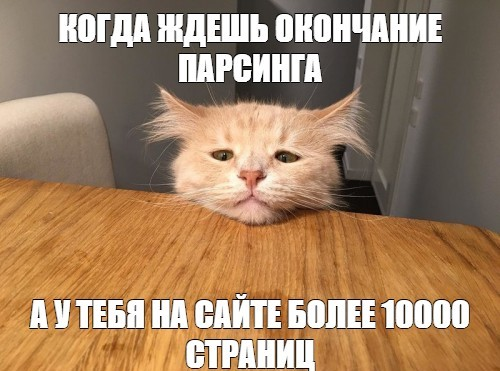

In [ ]:
def parser(page):
    # берем описания книги со страницы книги
    book_links = page.locator("h3 a")
    descriptions = []
    for i in range(book_links.count()):
        # Кликаем на ссылку
        with page.expect_navigation():
            book_links.nth(i).click()
        # берем описание со страницы книги
        descriptions.append(page.locator("#product_description + p").text_content())
        # Возвращаемся назад
        page.go_back()

    df = pd.DataFrame(data, columns=['Описание'])
    print(df)

## Пагинация. Учимся ходить по страницам сайта

In [ ]:
from playwright.sync_api import sync_playwright
import pandas as pd

url = "https://books.toscrape.com/"

with sync_playwright() as p:
    browser = p.chromium.launch(headless=False)
    page = browser.new_page()

    all_data = []

    # Начинаем с первой страницы
    page.goto(url)

    while True:
        # Парсим текущую страницу
        books = page.locator("article.product_pod")
        for i in range(books.count()):
            book = books.nth(i)
            title = book.locator("h3 a").text_content()
            price = book.locator("p.price_color").text_content()
            all_data.append([title, price])

        # Проверяем есть ли следующая страница
        if page.locator("li.next a").is_visible():
            # Кликаем на "Next"
            page.locator("li.next a").click()
            page.wait_for_load_state("domcontentloaded")
        else:
            break  # Нет больше страниц - выходим

    browser.close()

df = pd.DataFrame(all_data, columns=['Название', 'Цена'])
print(f"Всего книг: {len(df)}")
print(df)
df.to_csv("all_books.csv", index=False)

## Скачать все книги сайта с описаниями